In [1]:
import re
import math
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
def parse_nist_report(report_path: Path) -> pd.DataFrame:
    text = report_path.read_text(errors="ignore")

    line_re = re.compile(
        r"""^
        \s*(?:\d+\s+){10}
        (?P<pval>[0-9]*\.[0-9]+)
        (?:\s+\*)?
        \s+(?P<pass_num>\d+)\s*/\s*(?P<pass_den>\d+)
        \s+(?:\*\s+)?
        (?P<test>.+?)\s*$
        """,
        re.MULTILINE | re.VERBOSE
    )

    rows = []
    for m in line_re.finditer(text):
        test = re.sub(r"\s+", " ", m.group("test").replace("*", "")).strip()
        rows.append({
            "test": test,
            "p_value": float(m.group("pval")),
            "pass_num": int(m.group("pass_num")),
            "pass_den": int(m.group("pass_den")),
        })

    if not rows:
        raise ValueError(f"Nenhum teste encontrado em {report_path.name}")

    df = pd.DataFrame(rows)
    df["proportion"] = df["pass_num"] / df["pass_den"]
    return df


In [9]:
def plot_nist_report(
    report_path: Path,
    show_xticks: bool = True,
    agg_mode: str = "worst",
    alpha: float = 0.01
):
    df = parse_nist_report(report_path)

    # Agregação
    if agg_mode == "worst":
        agg = (df.groupby("test", as_index=False)
                 .agg(p_value=("p_value", "min"),
                      proportion=("proportion", "min"),
                      pass_den=("pass_den", "max"),
                      n_rows=("p_value", "size")))
    elif agg_mode == "mean":
        agg = (df.groupby("test", as_index=False)
                 .agg(p_value=("p_value", "mean"),
                      proportion=("proportion", "mean"),
                      pass_den=("pass_den", "max"),
                      n_rows=("p_value", "size")))
    else:
        raise ValueError("agg_mode deve ser 'worst' ou 'mean'")

    # Ordem padrão NIST
    order = [
        "Frequency","BlockFrequency","CumulativeSums","Runs",
        "LongestRun","Rank","FFT","NonOverlappingTemplate",
        "OverlappingTemplate","Universal","ApproximateEntropy",
        "RandomExcursions","RandomExcursionsVariant","Serial","LinearComplexity"
    ]

    present = [t for t in order if t in agg["test"].values]
    extras = [t for t in agg["test"].values if t not in present]
    plot_order = present + extras

    agg["order"] = agg["test"].apply(lambda x: plot_order.index(x))
    agg = agg.sort_values("order").reset_index(drop=True)

    # Limite de proporção por denominador
    p_hat = 1 - alpha
    agg["min_pass_rate"] = agg["pass_den"].apply(
        lambda m: p_hat - 3 * math.sqrt(p_hat * (1 - p_hat) / m)
    )

    # === Plot ===
    fig = plt.figure(figsize=(14, 7))

    # Painel superior: p-values
    ax1 = plt.subplot(2, 1, 1)
    ax1.bar(range(len(agg)), agg["p_value"])
    ax1.set_yscale("log")
    ax1.axhline(alpha, linewidth=2)
    ax1.set_ylabel("P-value", fontsize=35)
    ax1.set_xticks([])

    ax1.tick_params(axis="y", labelsize=30)
    x = range(len(agg))
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(
        [str([i]) for i in range(1, len(agg) + 1)], fontsize=22
    )

    # ax1.set_title(
    #     f"NIST SP 800-22 — {report_path.name}",
    #     fontsize=20
    # )

    # Painel inferior: proporção
    ax2 = plt.subplot(2, 1, 2)
    x = range(len(agg))
    ax2.scatter(x, agg["proportion"], s=60)
    ax2.plot(x, agg["min_pass_rate"], linewidth=2)

    ax2.set_ylabel("Proportion", fontsize=30)
    ax2.set_ylim(0.6, 1.001)

    ax2.tick_params(axis="y", labelsize=22)
    ax2.tick_params(axis="x", labelsize=22)

    ax2.set_xticks(list(x))
    ax2.set_xticklabels(
        [str([i]) for i in range(1, len(agg) + 1)], fontsize=22
    )

    # if show_xticks:
    #     ax2.set_xticks(list(x))
    #     ax2.set_xticklabels(agg["test"], rotation=70, ha="right", fontsize=30)
    # else:
    #     ax2.set_xticks([])
    #     ax2.set_xlabel("")



    plt.tight_layout()
    plt.savefig(f"{report_path.name[:-4]}.pdf", format="pdf")
    plt.show()


    return agg

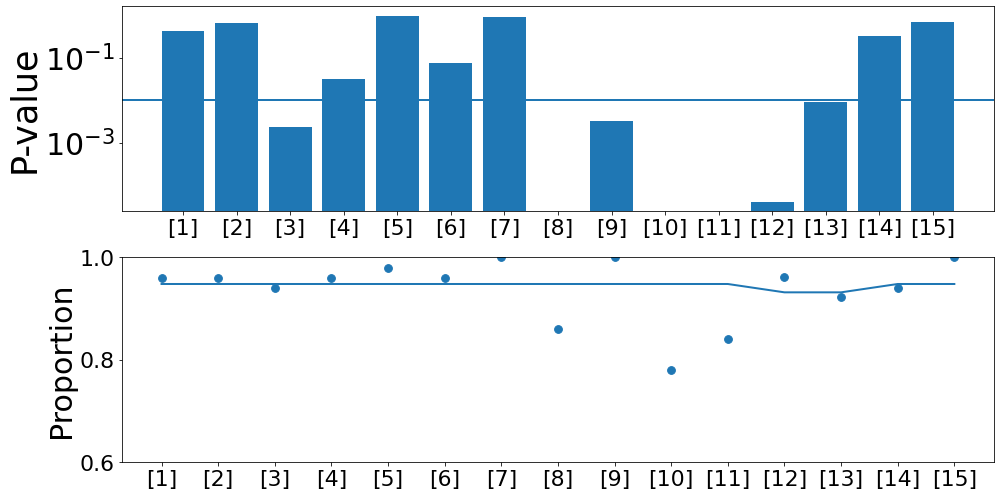

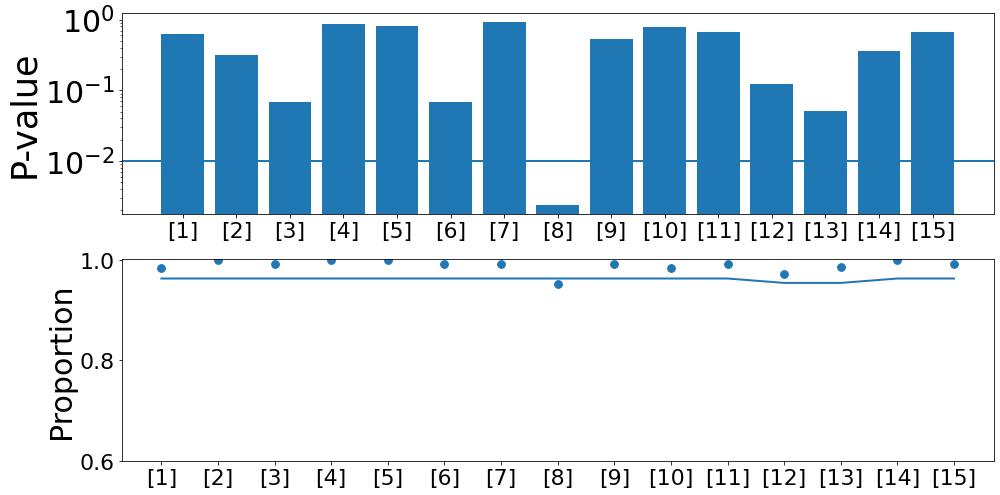

In [10]:
# 1º gráfico — QRNG bruto (SEM labels no eixo x)
agg_qrng = plot_nist_report(
    Path("finalAnalysisReport_50_QRNG.txt"),
    show_xticks=False
)

# 2º gráfico — QRNG + RanA (COM labels no eixo x)
agg_rana = plot_nist_report(
    Path("finalAnalysisReport_rana_extend_50M.txt"),
    show_xticks=True
)


### Dados para artigo

In [5]:
agg_rana

,test,p_value,proportion,pass_den,n_rows,order,min_pass_rate
0,Frequency,0.628443,0.983740,123,1,0,0.963086
1,BlockFrequency,0.317818,1.000000,123,1,1,0.963086
2,CumulativeSums,0.068642,0.991870,123,2,2,0.963086
3,Runs,0.855534,1.000000,123,1,3,0.963086
4,LongestRun,0.811993,1.000000,123,1,4,0.963086
5,Rank,0.068642,0.991870,123,1,5,0.963086
6,FFT,0.927083,0.991870,123,1,6,0.963086
7,NonOverlappingTemplate,0.002389,0.951220,123,148,7,0.963086
8,OverlappingTemplate,0.525771,0.991870,123,1,8,0.963086
9,Universal,0.796580,0.983740,123,1,9,0.963086


In [6]:
agg_qrng

,test,p_value,proportion,pass_den,n_rows,order,min_pass_rate
0,Frequency,0.419021,0.960000,50,1,0,0.947786
1,BlockFrequency,0.657933,0.960000,50,1,1,0.947786
2,CumulativeSums,0.002374,0.940000,50,2,2,0.947786
3,Runs,0.030806,0.960000,50,1,3,0.947786
4,LongestRun,0.971699,0.980000,50,1,4,0.947786
5,Rank,0.075719,0.960000,50,1,5,0.947786
6,FFT,0.911413,1.000000,50,1,6,0.947786
7,NonOverlappingTemplate,0.000000,0.860000,50,148,7,0.947786
8,OverlappingTemplate,0.003201,1.000000,50,1,8,0.947786
9,Universal,0.000000,0.780000,50,1,9,0.947786


In [7]:
import math

def min_pass_rate(m: int, alpha: float = 0.01) -> float:
    p_hat = 1 - alpha
    return p_hat - 3 * math.sqrt(p_hat * (1 - p_hat) / m)

def export_csv(agg, out_csv):
    # agg["p_value"] = agg["p_value"].clip(lower=1e-12)

    df_out = pd.DataFrame({
        "id": range(1, len(agg)+1),
        "p_value": agg["p_value"].values,
        "proportion": agg["proportion"].values,
        # se quiser a linha/curva do limite por m (um valor só, via mode):
        "min_pass_rate": [min_pass_rate(int(agg["pass_den"].mode().iloc[0]), 0.01)] * len(agg)
    })
    agg["p_value"] = agg["p_value"].clip(lower=1e-12)
    df_out.to_csv(out_csv, index=False)

export_csv(agg_qrng, "nist_qrng.csv")
export_csv(agg_rana, "nist_rana.csv")


In [ ]:
def plot_nist_report(
    report_path: Path,
    show_xticks: bool = True,
    agg_mode: str = "worst",
    alpha: float = 0.01
):
    df = parse_nist_report(report_path)

    # Agregação
    if agg_mode == "worst":
        agg = (df.groupby("test", as_index=False)
                 .agg(p_value=("p_value", "min"),
                      proportion=("proportion", "min"),
                      pass_den=("pass_den", "max"),
                      n_rows=("p_value", "size")))
    elif agg_mode == "mean":
        agg = (df.groupby("test", as_index=False)
                 .agg(p_value=("p_value", "mean"),
                      proportion=("proportion", "mean"),
                      pass_den=("pass_den", "max"),
                      n_rows=("p_value", "size")))
    else:
        raise ValueError("agg_mode deve ser 'worst' ou 'mean'")

    # Ordem padrão NIST
    order = [
        "Frequency","BlockFrequency","CumulativeSums","Runs",
        "LongestRun","Rank","FFT","NonOverlappingTemplate",
        "OverlappingTemplate","Universal","ApproximateEntropy",
        "RandomExcursions","RandomExcursionsVariant","Serial","LinearComplexity"
    ]

    present = [t for t in order if t in agg["test"].values]
    extras = [t for t in agg["test"].values if t not in present]
    plot_order = present + extras

    agg["order"] = agg["test"].apply(lambda x: plot_order.index(x))
    agg = agg.sort_values("order").reset_index(drop=True)

    # Limite de proporção por denominador
    p_hat = 1 - alpha
    agg["min_pass_rate"] = agg["pass_den"].apply(
        lambda m: p_hat - 3 * math.sqrt(p_hat * (1 - p_hat) / m)
    )

    # === Plot ===
    fig = plt.figure(figsize=(14, 7))

    # Painel superior: p-values
    ax1 = plt.subplot(1, 1, 1)
    ax1.bar(range(len(agg)), agg["p_value"])
    ax1.set_yscale("log")
    ax1.axhline(alpha, linewidth=2)
    ax1.set_ylabel("P-value", fontsize=30)
    ax1.set_xticks([])

    ax1.tick_params(axis="y", labelsize=22)
    x = range(len(agg))
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(
        [str([i]) for i in range(1, len(agg) + 1)], fontsize=30
    )

    # ax1.set_title(
    #     f"NIST SP 800-22 — {report_path.name}",
    #     fontsize=20
    # )

    # Painel inferior: proporção
    # ax2 = plt.subplot(2, 1, 2)
    # x = range(len(agg))
    # ax2.scatter(x, agg["proportion"], s=60)
    # ax2.plot(x, agg["min_pass_rate"], linewidth=2)

    # ax2.set_ylabel("Proportion", fontsize=30)
    # ax2.set_ylim(0.6, 1.001)

    # ax2.tick_params(axis="y", labelsize=22)
    # ax2.tick_params(axis="x", labelsize=22)

    # ax2.set_xticks(list(x))
    # ax2.set_xticklabels(
    #     [str([i]) for i in range(1, len(agg) + 1)], fontsize=30
    # )

    # if show_xticks:
    #     ax2.set_xticks(list(x))
    #     ax2.set_xticklabels(agg["test"], rotation=70, ha="right", fontsize=30)
    # else:
    #     ax2.set_xticks([])
    #     ax2.set_xlabel("")



    plt.tight_layout()
    plt.savefig(f"{report_path.name[:-4]}.pdf", format="pdf")
    plt.show()


    return agg